In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [2]:
house_prediction_data = pd.read_csv("datasets/HousePricePrediction.csv")
house_prediction = house_prediction_data.copy()

In [3]:
house_prediction.sample(5)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2201,2201,70,RL,7609,Corner,1Fam,9,1925,1997,Stucco,0.0,798.0,NaN
2114,2114,50,RM,6000,Inside,1Fam,7,1940,1989,Wd Sdng,0.0,981.0,NaN
1598,1598,120,RM,3907,Inside,TwnhsE,6,1989,1989,HdBoard,0.0,982.0,NaN
525,525,20,FV,7500,Inside,1Fam,5,2005,2005,VinylSd,0.0,1257.0,176000.0
2689,2689,60,FV,13162,Corner,1Fam,5,2006,2006,VinylSd,0.0,2036.0,NaN


In [4]:
house_prediction = house_prediction.dropna(subset=["SalePrice"])

In [5]:
house_prediction = house_prediction.drop("Id", axis=1)

In [6]:
house_prediction = house_prediction.drop_duplicates()

In [7]:
house_prediction_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [8]:
X = house_prediction.drop(columns=["SalePrice"])
y = house_prediction["SalePrice"]

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

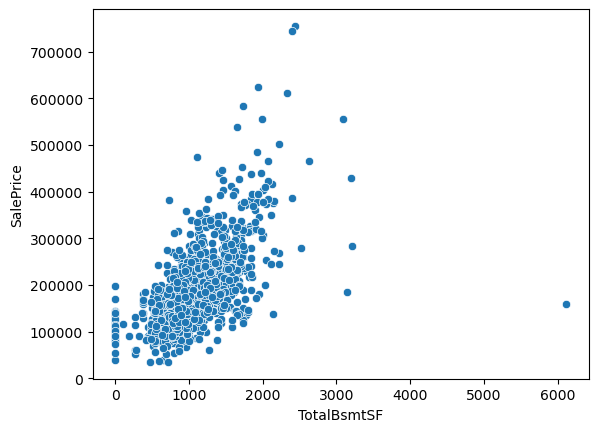

In [9]:
sns.scatterplot(data=house_prediction, x="TotalBsmtSF", y="SalePrice")

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, test_size=0.2, random_state=40)

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 609 to 1350
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    1168 non-null   int64  
 1   MSZoning      1168 non-null   object 
 2   LotArea       1168 non-null   int64  
 3   LotConfig     1168 non-null   object 
 4   BldgType      1168 non-null   object 
 5   OverallCond   1168 non-null   int64  
 6   YearBuilt     1168 non-null   int64  
 7   YearRemodAdd  1168 non-null   int64  
 8   Exterior1st   1168 non-null   object 
 9   BsmtFinSF2    1168 non-null   float64
 10  TotalBsmtSF   1168 non-null   float64
dtypes: float64(2), int64(5), object(4)
memory usage: 109.5+ KB


In [12]:
X_train.sample(5)

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
879,20,RL,7000,CulDSac,1Fam,8,1978,2005,VinylSd,0.0,864.0
9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0
344,160,RM,2592,Inside,TwnhsE,3,1976,1976,CemntBd,232.0,536.0
1042,120,RL,5381,Inside,Twnhs,5,2005,2005,VinylSd,0.0,1306.0
1236,160,RL,2628,Inside,Twnhs,5,2003,2003,VinylSd,0.0,764.0


In [13]:
# Cleaning data
# Missing values
X_train["MSZoning"] = X_train["MSZoning"].fillna(X_train["MSZoning"].mode()[0])
X_train["Exterior1st"] = X_train["Exterior1st"].fillna(X_train["Exterior1st"].mode()[0])
X_train["BsmtFinSF2"] = X_train["BsmtFinSF2"].fillna(X_train["BsmtFinSF2"].median())
X_train["TotalBsmtSF"] = X_train["TotalBsmtSF"].fillna(X_train["TotalBsmtSF"].median())
y_train = y_train.fillna(y_train.median())

In [14]:
# For test data
X_test["MSZoning"] = X_test["MSZoning"].fillna(X_test["MSZoning"].mode()[0])
X_test["Exterior1st"] = X_test["Exterior1st"].fillna(X_test["Exterior1st"].mode()[0])
X_test["BsmtFinSF2"] = X_test["BsmtFinSF2"].fillna(X_test["BsmtFinSF2"].median())
X_test["TotalBsmtSF"] = X_test["TotalBsmtSF"].fillna(X_test["TotalBsmtSF"].median())
y_test = y_test.fillna(y_test.median())
X_train

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
609,20,RL,7943,Inside,1Fam,5,1961,1961,VinylSd,0.0,1029.0
1361,20,RL,16158,Inside,1Fam,5,2005,2005,VinylSd,0.0,1530.0
1076,50,RL,10800,Inside,1Fam,8,1936,1989,Wd Sdng,0.0,796.0
1138,20,RL,9819,Inside,1Fam,5,1977,1977,Plywood,0.0,1567.0
1159,60,RL,9120,Inside,1Fam,6,1974,1974,HdBoard,0.0,901.0
...,...,...,...,...,...,...,...,...,...,...,...
1016,20,RL,11883,Inside,1Fam,5,1996,1996,VinylSd,0.0,1504.0
165,190,RL,10106,Inside,2fmCon,7,1940,1999,Wd Sdng,181.0,644.0
7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0
219,120,RL,3010,Inside,TwnhsE,5,2005,2006,VinylSd,0.0,1248.0


In [15]:
# feature engineering
ohe = OneHotEncoder(sparse_output = False, handle_unknown="ignore", drop="first").set_output(transform = "pandas")
ohe.fit(X_train[["MSZoning", "LotConfig", "BldgType", "Exterior1st"]])
X_train_transformed = ohe.transform(X_train[["MSZoning", "LotConfig", "BldgType", "Exterior1st"]])
X_train = pd.concat([X_train, X_train_transformed], axis=1).drop(["MSZoning", "LotConfig", "BldgType", "Exterior1st"], axis=1)
X_test_transformed = ohe.transform(X_test[["MSZoning", "LotConfig", "BldgType", "Exterior1st"]])
X_test = pd.concat([X_test, X_test_transformed], axis=1).drop(["MSZoning", "LotConfig", "BldgType", "Exterior1st"], axis=1)

In [16]:
# Scaling
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
609,-0.871658,-0.252659,-0.504499,-0.358283,-1.174415,-0.287698,-0.067266,-0.215859,-0.097506,0.512545,...,-0.213677,-0.418390,-0.029273,-0.402727,-0.287200,-0.029273,-0.131991,1.339499,-0.408452,-0.138554
1361,-0.871658,0.498726,-0.504499,1.110048,0.968512,-0.287698,1.049542,-0.215859,-0.097506,0.512545,...,-0.213677,-0.418390,-0.029273,-0.402727,-0.287200,-0.029273,-0.131991,1.339499,-0.408452,-0.138554
1076,-0.165219,0.008656,2.223533,-1.192562,0.189266,-0.287698,-0.586660,-0.215859,-0.097506,0.512545,...,-0.213677,-0.418390,-0.029273,-0.402727,-0.287200,-0.029273,-0.131991,-0.746548,2.448267,-0.138554
1138,-0.871658,-0.081071,-0.504499,0.175656,-0.395169,-0.287698,1.132020,-0.215859,-0.097506,0.512545,...,-0.213677,-0.418390,-0.029273,-0.402727,3.481895,-0.029273,-0.131991,-0.746548,-0.408452,-0.138554
1159,0.070261,-0.145005,0.404845,0.075542,-0.541277,-0.287698,-0.352598,-0.215859,-0.097506,0.512545,...,-0.213677,2.390114,-0.029273,-0.402727,-0.287200,-0.029273,-0.131991,-0.746548,-0.408452,-0.138554


In [17]:
X_train_transformed.columns == X_test_transformed.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [18]:
X_train.sample()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
664,-0.871658,0.932087,-0.504499,1.110048,1.017214,-0.287698,2.268891,-0.215859,-0.097506,0.512545,...,-0.213677,-0.41839,-0.029273,-0.402727,-0.2872,-0.029273,-0.131991,1.339499,-0.408452,-0.138554


In [19]:
X_test.sample()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
967,-0.871658,-0.303239,1.314189,-0.55851,-1.466632,-0.287698,0.086546,-0.215859,-0.097506,0.512545,...,-0.213677,-0.41839,-0.029273,-0.402727,-0.2872,-0.029273,-0.131991,-0.746548,2.448267,-0.138554


In [20]:
print(len(X_train.columns), len(X_test.columns))

33 33


In [21]:
X_train.columns == X_test.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_test_predicted = model.predict(X_test)

In [24]:
r2 = r2_score(y_test, y_test_predicted)
n, p = X_test.shape
adjusted_r2 = 1  - ((1 - r2) * (n - 1) / (n - p - 1))
print("R2:", r2, "\nAdjusted R2:", adjusted_r2)

R2: 0.6345242104163474 
Adjusted R2: 0.5877773070975081


In [25]:
y_train_predicted = model.predict(X_train)
r2 = r2_score(y_train, y_train_predicted)
n, p = X_train.shape
adjusted_r2 = 1  - ((1 - r2) * (n - 1) / (n - p - 1))
print("R2:", r2, "\nAdjusted R2:", adjusted_r2)

R2: 0.6117945771684641 
Adjusted R2: 0.6004975939643717


In [26]:
alphas = [0.001, 0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 10, 20, 30, 40, 50]
model = LassoCV(alphas = alphas, cv = 10, max_iter=1000)
model.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
mse = mean_squared_error(y_test, y_test_predicted)
print("MSE at", model.alpha_, "=", mse) 

MSE at 50.0 = 1878813769.852952


In [31]:
# Polynomial regression
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]    
)
pipe.fit(X_train, y_train)

y_test_pred = pipe.predict(X_test)

print("R2:", r2_score(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

R2: -186.9401863937006
MSE: 970268125822.8468
